# Feature selection

A QSAR classification model for small-molecule BRD4 inhibitors was built and tested on a set of novel candidates.  

# Setup Code
## Environment

In [1]:
### use brd4

import sys

print(sys.executable)

/home/oskar/anaconda3/envs/brd4/bin/python


## Imports

In [26]:
import copy
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
from rdkit import RDLogger
from tqdm import tqdm

## Jupyter Settings

In [ ]:
### Random seed - using the same seed for robustness
SEED = 42
np.random.seed(SEED)

### NumPy arrays - floats
np.set_printoptions(
    precision=2,  # round values
    suppress=True,
)  # avoid scientific notation

### pandas DataFrames
pd.set_option("display.float_format", "{:.2f}".format)  # Round to 2 decimal places

### Initialize tqdm for pandas
tqdm.pandas()

### Suppress RDKit logs
RDLogger.DisableLog("rdApp.*")

### Re-enable logging if needed
# RDLogger.EnableLog('rdApp.*')

## Utils
- `utils/pd_mol.py` contains individual functions for processing rdkit mol objects in pandas DataFrames

In [ ]:
### Add the utils directory to the path
sys.path.append(os.path.abspath("../utils"))

from pd_mol import render_mol
from similarity_sali import MorganSimilarity

## Functions

### Classification metrics

In [ ]:
### Function to evaluate a classifier model with bagging with multiple metrics
def rf_perf_fx(model, X_train, X_test, y_train, y_test):
    # Get OOB predictions for the training set
    oob_predictions = model.oob_decision_function_

    # For binary classification, convert OOB decision function to predicted classes
    oob_predicted_classes = (oob_predictions[:, 1] >= 0.5).astype(int)

    # Get predictions for the test set
    y_test_pred = model.predict(X_test)

    # Calculate metrics for the OOB predictions (used as 'test' column)
    accuracy_oob = sk.metrics.accuracy_score(y_train, oob_predicted_classes)
    # balanced_acc_oob = sk.metrics.balanced_accuracy_score(y_train, oob_predicted_classes)
    sensitivity_oob = sk.metrics.recall_score(y_train, oob_predicted_classes)
    tn_oob, fp_oob, fn_oob, tp_oob = sk.metrics.confusion_matrix(
        y_train, oob_predicted_classes
    ).ravel()
    specificity_oob = tn_oob / (tn_oob + fp_oob)
    mcc_oob = matthews_corrcoef(y_train, oob_predicted_classes)  # Calculate MCC for OOB
    roc_auc_oob = roc_auc_score(y_train, oob_predicted_classes)

    # Calculate metrics for the test set
    accuracy_test = sk.metrics.accuracy_score(y_test, y_test_pred)
    # balanced_acc_test = sk.metrics.balanced_accuracy_score(y_test, y_test_pred)
    sensitivity_test = sk.metrics.recall_score(y_test, y_test_pred)
    tn_test, fp_test, fn_test, tp_test = sk.metrics.confusion_matrix(
        y_test, y_test_pred
    ).ravel()
    specificity_test = tn_test / (tn_test + fp_test)
    mcc_test = matthews_corrcoef(y_test, y_test_pred)  # Calculate MCC for test set
    roc_auc = roc_auc_score(y_test, y_test_pred)

    # Create a DataFrame with metrics as rows and columns for 'train' and 'test'
    metrics_df = pd.DataFrame(
        {
            "oob": [
                accuracy_oob,
                sensitivity_oob,
                specificity_oob,
                mcc_oob,
                roc_auc_oob,
            ],
            "test": [
                accuracy_test,
                sensitivity_test,
                specificity_test,
                mcc_test,
                roc_auc,
            ],
        },
        index=["Accuracy", "Sensitivity", "Specificity", "MCC", "ROC_AUC"],
    )

    return metrics_df


### Function to evaluate the classifier model with multiple metrics
def clf_perf_fx(model, X_train, X_test, y_train, y_test):
    # Get predictions for the training set
    y_train_pred = model.predict(X_train)

    # Get predictions for the test set
    y_test_pred = model.predict(X_test)

    # Calculate metrics for the training set
    accuracy_train = sk.metrics.accuracy_score(y_train, y_train_pred)
    # balanced_acc_train = sk.metrics.balanced_accuracy_score(y_train, y_train_pred)
    sensitivity_train = sk.metrics.recall_score(y_train, y_train_pred)
    tn_train, fp_train, fn_train, tp_train = sk.metrics.confusion_matrix(
        y_train, y_train_pred
    ).ravel()
    specificity_train = tn_train / (tn_train + fp_train)
    mcc_train = matthews_corrcoef(y_train, y_train_pred)  # Calculate MCC for train set
    roc_auc_train = roc_auc_score(y_train, y_train_pred)

    # Calculate metrics for the test set
    accuracy_test = sk.metrics.accuracy_score(y_test, y_test_pred)
    # balanced_acc_test = sk.metrics.balanced_accuracy_score(y_test, y_test_pred)
    sensitivity_test = sk.metrics.recall_score(y_test, y_test_pred)
    tn_test, fp_test, fn_test, tp_test = sk.metrics.confusion_matrix(
        y_test, y_test_pred
    ).ravel()
    specificity_test = tn_test / (tn_test + fp_test)
    mcc_test = matthews_corrcoef(y_test, y_test_pred)  # Calculate MCC for test set
    roc_auc_test = roc_auc_score(y_test, y_test_pred)

    # Create a DataFrame with metrics as rows and columns for 'train' and 'test'
    metrics_df = pd.DataFrame(
        {
            "train": [
                accuracy_train,
                sensitivity_train,
                specificity_train,
                mcc_train,
                roc_auc_train,
            ],
            "test": [
                accuracy_test,
                sensitivity_test,
                specificity_test,
                mcc_test,
                roc_auc_test,
            ],
        },
        index=["Accuracy", "Sensitivity", "Specificity", "MCC", "ROC_AUC"],
    )

    return metrics_df

# Data
To ensure reproducibility `01_brd4_inhibitors_2k.pkl` generated [here](../01_eda/01_pre_process.ipynb) is used for this analysis. They are described by (columns):
- `ID`: string - unique identifier from `ChEMBL`
- `Mol`: rdkit.Chem.rdchem.Mol - standardized inhibitor structure 
- `pIC50`: float - quantitative activity (negative logarithm of the half maximal inhibitory concentration in `mol / L`). 
- `active`: float - 1.00 (active), 0.00 (inactive)

,Mol,pIC50,active
ID,,,
CHEMBL1232461,,7.01,1.00
CHEMBL1233528,,6.92,1.00
CHEMBL1313432,,5.18,0.00

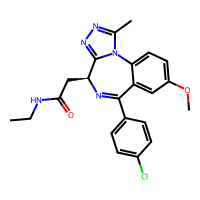
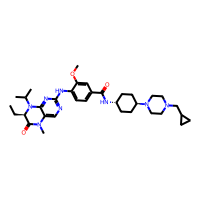
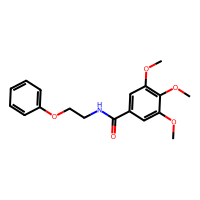

In [ ]:
df = pd.read_pickle("../data/01_brd4_inhibitors_2k.pkl")
render_mol(df.head(3))

# Dimension reduction with PCA

## Morgan fingerprints

From the [SALI analysis](../01_eda/02_activity_cliffs.ipynb) we know that `radius = 3` is important for this data set. Because we will reduce the complexity by PCA `nBits = 2048` is chosen. 

The method `utils.similarity_sali.MorganSimilarity.get_morgan_fingerprint()` is used to calculate the fingerprints. 

In [ ]:
### Instantiate the class
morgan = MorganSimilarity(df, radius=3, nBits=2048, useChirality=True)

### Get the Morgan fingerprints
morgan.get_morgan_fingerprint()

### Format the fingerprints as NumPy array
morgan.format_fp("np_array")

morgan.fp

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2397, 2048))

## Variance Analysis
Principal component analysis (PCA) ranks new features by the amount of variance each PC explains. If plotted in a cumulative fashion, the amount of variance explained for any number of chosen PCs.

In [66]:
### Instantiate the PCA class
pca = sk.decomposition.PCA(random_state=SEED)

### Fit the PCA model
all_PCs = pca.fit_transform(morgan.fp)

228 PCs explain 80.0% of the variance: 


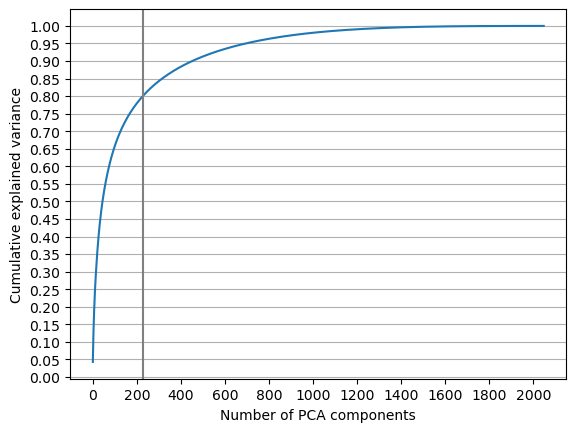

In [30]:
### Filter cumulative_variance for explaining 80% of the variance (choose between 80-95% based on elbow point)
explained_variance_threshold = 0.80

### Cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

### Find the index where cumulative variance exceeds threshold
num_components = np.argmax(cumulative_variance >= explained_variance_threshold) + 1

print(
    f"{num_components} PCs explain {explained_variance_threshold * 100}% of the variance: "
)

### Plot
features = range(pca.n_components_)

plt.plot(features, cumulative_variance)
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.xticks(np.arange(0, morgan.nBits, 200))
plt.yticks(np.arange(0, 1.05, 0.05))
plt.grid(True, which="both", axis="y")
plt.axvline(x=num_components, color="grey")
plt.show()

## Bias Analysis
### Accuracy Score
Because both classes are balanced, the choice of scoring metric is not crucial. **Accuracy** will be used as scoring metric. 

In [ ]:
print(round(df["active"].mean(), 3), df["active"].value_counts())

0.496 active
0.00    1209
1.00    1188
Name: count, dtype: int64


For inbalanced data sets use multiple scoring metrics

- **Accuracy**:       Overall model correctness
- **Sensitivity**:    1 - false negative rate
- **Specificity**:    1 - false positive rate
- **MCC**:            Matthews Correlation Coefficient
- **ROC_AUC**:        includes prediction confidence

### Out-of-Bag Score
A random forest classifier with default hyperparameters will be used for feature selection. This allows the use of out-of-bag (OOB) scoring and thus removes the need for splitting the data set in train and test data. 

In [72]:
def train_oob(X, y, n_components):
    
    ### Instantiate Random Forest Classifier
    rf_clf = sk.ensemble.RandomForestClassifier(
        oob_score=True,  # quasi test score
        random_state=SEED, # reproducability
    )

    ### Subset the features for n PCs
    X_subset = X[:, :int(n_components)]

    ### Fit the model with n PCs
    rf_clf.fit(X_subset, y)  

    ### Calculate the training accuracy
    train_score = sk.metrics.accuracy_score(y, rf_clf.predict(X_subset))

    ### Calculate the OOB score (uses accuracy as default)
    oob_score = rf_clf.oob_score_

    return train_score, oob_score

In [73]:
score_df = pd.DataFrame(np.logspace(0, 11, num=12, base=2).astype(int), columns=['n_PCs'])
score_df['cum_var'] = cumulative_variance[score_df['n_PCs'] - 1]
score_df[['train_score', 'oob_score']] = score_df.progress_apply(lambda row: train_oob(all_PCs, df['active'].values, row['n_PCs']), axis=1, result_type='expand')
score_df

  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:51<00:00,  4.27s/it]


,n_PCs,cum_var,train_score,oob_score
0,1,0.04,1.00,0.59
1,2,0.08,1.00,0.74
2,4,0.13,1.00,0.83
3,8,0.21,1.00,0.87
4,16,0.31,1.00,0.88
5,32,0.43,1.00,0.89
6,64,0.57,1.00,0.90
7,128,0.70,1.00,0.91
8,256,0.82,1.00,0.91
9,512,0.92,1.00,0.90


# Sandbox

In [70]:
score_df.dtypes

n_PCs        int64
cum_var    float64
dtype: object

# Old code

In [ ]:
### Initialize an empty DataFrame to collect all results
all_metrics_df = pd.DataFrame()

### Loop through each descriptor space
for name, (X_train, X_test) in tqdm(initial_descriptor_spaces.items()):
    ### Data fitting
    rf_default.fit(X_train, y_train)
    ### Calculating classification metrics
    perf_df_oob = rf_perf_fx(rf_default, X_train, X_test, y_train, y_test)

    #### Rename the columns to include the descriptor space
    perf_df_oob.columns = [f"{col}{name}" for col in perf_df_oob.columns]
    ### Concatenate the metrics DataFrame for this iteration to the overall DataFrame
    all_metrics_df = pd.concat([all_metrics_df, perf_df_oob], axis=1)

all_metrics_df["Comment"] = metric_comments

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.14it/s]


In [42]:
rf_default_metrics = copy.deepcopy(all_metrics_df)
rf_default_metrics

,oob20,test20,oob142,test142,oob1024,test1024,Comment
Accuracy,0.87,0.93,0.88,0.94,0.91,0.96,Overall model correctness
Sensitivity,0.86,0.93,0.89,0.94,0.93,0.97,1 - false negative rate
Specificity,0.88,0.94,0.88,0.94,0.90,0.95,1 - false positive rate
MCC,0.74,0.86,0.77,0.88,0.83,0.92,Matthews Correlation Coefficient
ROC_AUC,0.87,0.93,0.88,0.94,0.91,0.96,includes prediction confidence


**Conclusion**
- **ROC_AUC:** Due to the balanced nature of the data set multiple scoring metrics are not required and further steps will rely on ROC_AUC only.
- **OOB:** The constantly lower out-of-bag (oob) score demonstrates the expected similarity between training- and test-cmpds. Thus, emphasizing the need of a scoring method with randomized sampling.
- **PCA:** Only a small decrease in performance with drastic reduction of dimensionality is observed. This requires further investigation. 

# Algorithms

In [ ]:
### Dimensionality reduction with PCA using an 8-fold distribution of descriptor spaces
dimensions_8fold = [2, 16, 128, 1024]
descriptor_spaces_8fold, pca_model_8folds = dimensionality_reduction(
    dimensions_8fold, train_finger_np, test_finger_np
)

100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  7.24it/s]


In [ ]:
### ML models we are investigating
models = {
    "svm": svm.SVC(probability=False, random_state=random.seed(SEED)),
    "gnb": GaussianNB(),
    "knn": KNeighborsClassifier(),
    "rf": RandomForestClassifier(random_state=SEED),
    "GB": GradientBoostingClassifier(),
}

## Cross-validation with default hyperparameters

In [ ]:
### Instantiate cross-validation as robustness score
cv = StratifiedKFold(
    n_splits=5,  # k-fold CV
    shuffle=True,  # to shuffle our data
    random_state=SEED,
)  # for repeatability

In [ ]:
cv_mean_roc_auc_df = pd.DataFrame({"pca": dimensions_8fold})
test_roc_auc_df = pd.DataFrame({"pca": dimensions_8fold})
### Looping though all models
for model_name, model in models.items():
    print(model_name)

    cv_scores = []
    test_scores = []
    ### Looping through each descriptor space
    for name, (X_train, X_test) in tqdm(descriptor_spaces_8fold.items()):
        ### Calculating average roc_auc_score for training data from cross-validation
        roc_auc_cv = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
        cv_scores.append(np.mean(roc_auc_cv))

        ### Fitting the whole training set
        model.fit(X_train, y_train)

        ### Calculating roc_auc_score for predicted test data
        y_test_pred = model.predict(X_test)
        roc_auc_test = roc_auc_score(y_test, y_test_pred)
        test_scores.append(roc_auc_test)

    ### Save metrics to DataFrame
    cv_mean_roc_auc_df[model_name] = cv_scores
    test_roc_auc_df[model_name] = test_scores

### Indexing
cv_mean_roc_auc_df = cv_mean_roc_auc_df.set_index("pca")
test_roc_auc_df = test_roc_auc_df.set_index("pca")


svm


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:07<00:00,  1.95s/it]


gnb


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 15.53it/s]


knn


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  8.92it/s]


rf


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:13<00:00,  3.31s/it]


GB


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:59<00:00, 14.78s/it]


In [47]:
### Splitting for cross-validation is random
cv_mean_roc_auc_df

,svm,gnb,knn,rf,GB
pca,,,,,
2,0.78,0.66,0.81,0.82,0.81
16,0.93,0.85,0.93,0.93,0.92
128,0.96,0.90,0.95,0.95,0.94
1024,0.96,0.79,0.95,0.96,0.95


In [48]:
### Splittiing of test set was based on structural similarity
test_roc_auc_df

,svm,gnb,knn,rf,GB
pca,,,,,
2,0.79,0.64,0.80,0.81,0.80
16,0.93,0.84,0.93,0.93,0.90
128,0.95,0.88,0.94,0.94,0.92
1024,0.95,0.91,0.95,0.96,0.93


continue with SVM, KNN and RF and pca 32

**Conclusion**:
- **models**: 
    - Gaussian Naive Bayes (gnb) is rejected due to it's performance across descriptor spaces. 
    - Gradient Boosting Classifier (GB) is reject due to it's performance and computational demand. 
    - RandomForest, SVM, and KNN are selecting for further investigation

# Descriptor spaces
All three (svm, knn, and rf) preform comparably across descriptor spaces tested so far. Due to it's fast processing speed KNN will be used to investigate descriptor spaces for all three models in more detail. 

In [ ]:
cv_mean_roc_auc_df[["svm", "knn", "rf"]]

,svm,knn,rf
pca,,,
2,0.78,0.81,0.82
16,0.93,0.93,0.93
128,0.96,0.95,0.95
1024,0.96,0.95,0.96


## Cross-validation with KNN

In [ ]:
### Dimensionality reduction with PCA using an 8-fold distribution of descriptor spaces
dimensions_log = [2, 4, 8, 10, 12, 14, 16, 24, 32, 48, 64, 128, 1024]
descriptor_spaces_log, pca_model_log = dimensionality_reduction(
    dimensions_log, train_finger_np, test_finger_np
)

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:01<00:00,  6.55it/s]


In [51]:
### Instantiate KNN
knn = KNeighborsClassifier()

In [ ]:
### Instantiate cross-validation as robustness score
cv = StratifiedKFold(
    n_splits=7,  # k-fold CV
    shuffle=True,  # to shuffle our data
    random_state=SEED,
)  # for repeatability

In [ ]:
knn_roc_auc_df = pd.DataFrame({"pca": dimensions_log})
cv_scores = []
test_scores = []
### Looping through each descriptor space
for name, (X_train, X_test) in tqdm(descriptor_spaces_log.items()):
    ### Calculating average roc_auc_score for training data from cross-validation
    roc_auc_cv = cross_val_score(knn, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_scores.append(roc_auc_cv)

    ### Fitting the whole training set
    knn.fit(X_train, y_train)

    ### Calculating roc_auc_score for predicted test data
    y_test_pred = knn.predict(X_test)
    roc_auc_test = roc_auc_score(y_test, y_test_pred)
    test_scores.append(roc_auc_test)

### DataFrame for individual cross-validation scores
cv_df = pd.DataFrame(cv_scores)
cv_df.set_index(knn_roc_auc_df["pca"], inplace=True)

### Save metrics to DataFrame
knn_roc_auc_df["test"] = test_scores
knn_roc_auc_df.set_index("pca", inplace=True)

### Calculate cross-validation metrics
knn_roc_auc_df["cv_mean"] = cv_df.mean(axis=1)
knn_roc_auc_df["cv_std"] = cv_df.std(axis=1)

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:01<00:00,  9.87it/s]


In [54]:
knn_roc_auc_df

,test,cv_mean,cv_std
pca,,,
2,0.80,0.81,0.03
4,0.87,0.87,0.02
8,0.91,0.92,0.02
10,0.92,0.93,0.01
12,0.92,0.93,0.01
14,0.93,0.93,0.01
16,0.93,0.93,0.01
24,0.93,0.94,0.01
32,0.93,0.94,0.01


C:\Users\wadh5096\Anaconda3\envs\neovarsity\lib\site-packages\ipykernel_launcher.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  


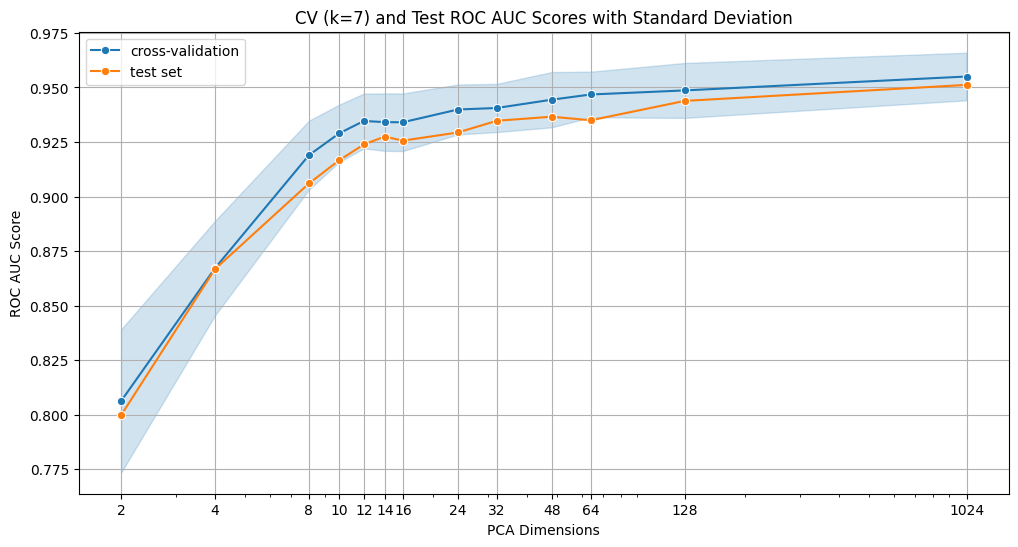

In [ ]:
### Melt the DataFrame to long format for Seaborn
tall_df = cv_df.reset_index().melt(
    id_vars="pca", var_name="fold", value_name="cv_score"
)

### Plot using Seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=tall_df, x="pca", y="cv_score", ci="sd", marker="o", label="cross-validation"
)
sns.lineplot(data=knn_roc_auc_df, x="pca", y="test", marker="o", label="test set")
# Customize the plot
plt.xscale("log")  # Set x-axis to logarithmic scale
plt.title("CV (k=7) and Test ROC AUC Scores with Standard Deviation")
plt.xlabel("PCA Dimensions")
plt.ylabel("ROC AUC Score")
plt.xticks(dimensions_log)
plt.gca().set_xticklabels(dimensions_log)
plt.legend()
plt.grid()
plt.show()

## Choose Descriptor space
**Conclusion**:
32 principal components are chosen as a compromise between performance and complexity reduction. 

In [56]:
X_train, X_test = descriptor_spaces_log[32]

In [57]:
pca_model = pca_model_log[32]

# Export data for hyperparameter tuning

## PCA model

In [ ]:
with open("temp/05_2_pca_32.pkl", "wb") as file:
    pickle.dump(pca_model, file)

## Training data

In [ ]:
with open("temp/05_2_train_data.pkl", "wb") as file:
    pickle.dump((idx_train, X_train, y_train), file)

## Test data

In [ ]:
with open("temp/05_2_test_data.pkl", "wb") as file:
    pickle.dump((idx_test, X_test, y_test), file)